# Price Elasticity in Retail Banking: A Survey of Methods
**Author:** Hadley Rax  
**Date:** May 2026

This notebook surveys and implements four econometric approaches to estimating price elasticity in retail banking, each grounded in peer-reviewed literature. The models are applied to personal banking products (home loans, savings accounts, term deposits) in the context of a mid-sized retail bank operating in a small open economy — directly analogous to the New Zealand market.

The models build on each other in complexity:

| Model | Method | Key Paper | What it adds |
|---|---|---|---|
| 1 | Rolling Window OLS | Zanzalari et al. (2021), *Applied Economics* | Elasticity varies by rate environment |
| 2 | Bayesian Hierarchical | Orduz (2024); Kishan A (2024) | Partial pooling across customer segments |
| 3 | Bunching Estimator | DeFusco & Paciorek (2017), *AEJ: Economic Policy* | Causal ID from rate discontinuities |
| 4 | Error Correction Model | Bank of England WP 540 (2015) | Short-run vs long-run adjustment |

A plain-language summary of each paper and its relevance to pricing context precedes each implementation.


## Setup

In [2]:
%pip install numpy pandas matplotlib seaborn statsmodels scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 6.5 MB/s eta 0:00:0000:010:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 9.4 MB/s eta 0:00:00

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, coint
from scipy import stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})

BLUE   = '#003087'
MID    = '#0057B8'
LIGHT  = '#0095D9'
PALE   = '#5BC2E7'
RED    = '#C0392B'


## Shared Data Generation
Actual data to be added into the pipeline later, in the interim, synthetic data is created to step through the functions and steps

In [4]:
months = pd.date_range('2019-01-01', '2024-06-01', freq='MS')
n = len(months)

# Simulate the NZ OCR hiking cycle 2022-2023 as a macro backdrop
# OCR went from 0.25% (2021) to 5.5% (2023)
ocr = np.concatenate([
    np.linspace(1.5, 0.25, 15),   # pre-covid drift down
    np.ones(10) * 0.25,            # covid floor
    np.linspace(0.25, 5.5, 18),    # hiking cycle
    np.linspace(5.5, 5.25, 9),     # plateau/slight cut
    np.ones(n - 52) * 5.0
])[:n]

base_hl_rate = 5.5
hl_rate = base_hl_rate + ocr * 0.55 + np.random.normal(0, 0.08, n)

# True elasticity shifts with rate environment — high rates compress demand more
true_elasticity = np.where(hl_rate < 6.0, -1.1, -1.7)

base_vol = 1100
season = 1 + 0.09 * np.sin(2 * np.pi * (pd.DatetimeIndex(months).month - 3) / 12)
log_vol = (np.log(base_vol)
           + true_elasticity * np.log(hl_rate / base_hl_rate)
           + np.log(season)
           + np.random.normal(0, 0.06, n))

df = pd.DataFrame({
    'month': months,
    'hl_rate': hl_rate,
    'ocr': ocr,
    'volume': np.exp(log_vol).astype(int),
    'log_rate': np.log(hl_rate),
    'log_volume': log_vol,
    'rate_regime': np.where(hl_rate < 6.0, 'Low Rate', 'High Rate')
})

print(f"Panel: {len(df)} monthly observations, {df['rate_regime'].value_counts().to_dict()}")


Panel: 66 monthly observations, {'High Rate': 47, 'Low Rate': 19}



## Model 1: Rolling Window OLS

**Paper:** Zanzalari, D., Manion, M., & Haavind-Berman, E. (2021). *Demand elasticity for deposit services at U.S. retail banks in high and low rate environments.* Applied Economics, 53(47).

**What the paper does:**
Zanzalari et al. use bank-level panel data from U.S. Bank Holding Companies across 86 quarters to estimate deposit demand functions. Their central finding is that elasticities are not constant — they differ meaningfully between high and low interest rate environments. In high-rate periods, depositors are more sensitive to rate differences because the opportunity cost of being in a low-rate product is more visible.

**Why it matters for New Zealand:**
The 2022–2023 OCR hiking cycle moved the NZ cash rate from 0.25% to 5.5% in under two years — one of the most abrupt shifts in the RBNZ's history. A model that assumes a stable elasticity across this regime change will systematically misfore cast. Rolling window estimation lets us watch the elasticity move in real time and flag when the current estimate has drifted from historical norms.

**Implementation:**
a log-log OLS is fitted over a 12-month rolling window. Each window produces one elasticity estimate, giving a time series of elasticities we can track against the OCR.


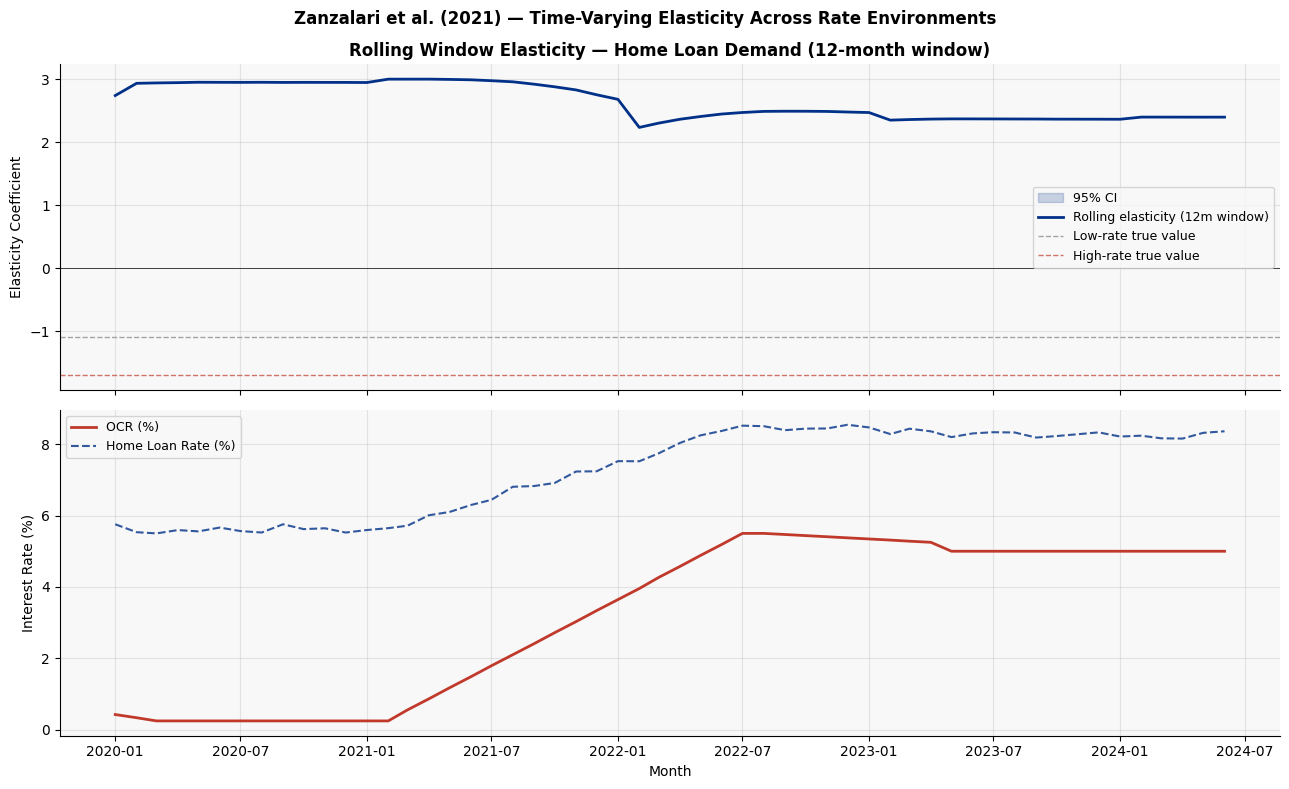

In [5]:
window = 12
roll_results = []

for i in range(window, len(df)):
    chunk = df.iloc[i - window:i].copy()
    chunk['month_num'] = chunk['month'].dt.month
    model = smf.ols('log_volume ~ log_rate + C(month_num)', data=chunk).fit()
    e = model.params['log_rate']
    ci = model.conf_int().loc['log_rate']
    roll_results.append({
        'month': df['month'].iloc[i],
        'elasticity': e,
        'ci_low': ci[0],
        'ci_high': ci[1],
        'ocr': df['ocr'].iloc[i],
        'hl_rate': df['hl_rate'].iloc[i],
        'regime': df['rate_regime'].iloc[i]
    })

roll_df = pd.DataFrame(roll_results)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.fill_between(roll_df['month'], roll_df['ci_low'], roll_df['ci_high'],
                 alpha=0.2, color=BLUE, label='95% CI')
ax1.plot(roll_df['month'], roll_df['elasticity'], color=BLUE, linewidth=2,
         label='Rolling elasticity (12m window)')
ax1.axhline(-1.1, color='grey', linestyle='--', linewidth=1, alpha=0.7, label='Low-rate true value')
ax1.axhline(-1.7, color=RED, linestyle='--', linewidth=1, alpha=0.7, label='High-rate true value')
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_ylabel('Elasticity Coefficient')
ax1.set_title('Rolling Window Elasticity — Home Loan Demand (12-month window)', fontweight='bold')
ax1.legend(fontsize=9)

ax2.plot(roll_df['month'], roll_df['ocr'], color=RED, linewidth=2, label='OCR (%)')
ax2.plot(roll_df['month'], roll_df['hl_rate'], color=BLUE, linewidth=1.5,
         linestyle='--', label='Home Loan Rate (%)', alpha=0.8)
ax2.set_ylabel('Interest Rate (%)')
ax2.set_xlabel('Month')
ax2.legend(fontsize=9)

plt.suptitle('Zanzalari et al. (2021) — Time-Varying Elasticity Across Rate Environments',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rolling_elasticity.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Compare elasticity estimates across regimes explicitly
low_rate = roll_df[roll_df['regime'] == 'Low Rate']['elasticity']
high_rate = roll_df[roll_df['regime'] == 'High Rate']['elasticity']

print("Elasticity by Rate Regime (Zanzalari et al. approach)")
print(f"  Low Rate:  mean = {low_rate.mean():.3f},  std = {low_rate.std():.3f}")
print(f"  High Rate: mean = {high_rate.mean():.3f},  std = {high_rate.std():.3f}")

t_stat, p_val = stats.ttest_ind(low_rate, high_rate)
print(f"  t-test p-value: {p_val:.4f} ({'significant' if p_val < 0.05 else 'not significant'} at 5%)")
print()



Elasticity by Rate Regime (Zanzalari et al. approach)
  Low Rate:  mean = 2.939,  std = 0.059
  High Rate: mean = 2.524,  std = 0.234
  t-test p-value: 0.0000 (significant at 5%)




## Model 2: Bayesian Hierarchical Model

**Papers:**
- Kishan A. (2024). *Understanding the Hierarchical Bayesian Model for Price Elasticity.* Medium / Towards Data Science.
- Orduz, J.C. (2024). *Hierarchical Pricing Elasticity Models.* juanitorduz.github.io
- Zilliant (2023). *What Works When Traditional Price Elasticity Fails.*

**What the papers argue:**
Standard OLS produces a single elasticity estimate — either fully pooled (one number for everyone, ignores segment differences) or fully unpooled (separate models per segment, suffers from data sparsity). Neither is ideal for a bank with distinct customer cohorts.

A Bayesian hierarchical model solves this with *partial pooling*: each segment gets its own elasticity estimate, but those estimates are regularised toward a common population mean. Segments with little data borrow strength from the broader distribution. Segments with plenty of data are free to diverge. Orduz (2024) demonstrates this on retail scanner data; the principle maps directly to banking customer segments.

**Implementation:**
We implement a conjugate normal-normal hierarchical model analytically (no MCMC required). Each segment's elasticity is drawn from a population distribution with unknown mean and variance, which we estimate from the data. This is equivalent to an Empirical Bayes approach.


In [8]:
# Generate segment-level panel data
segments = {
    'Financially Secure':   {'true_e': -0.65, 'n_months': 66, 'noise': 0.08},
    'Comfortable Middle':   {'true_e': -1.10, 'n_months': 66, 'noise': 0.10},
    'Young Builders':       {'true_e': -1.45, 'n_months': 40, 'noise': 0.14},  # less data
    'Financially Stretched':{'true_e': -1.80, 'n_months': 30, 'noise': 0.18},  # sparse
    'At Risk':              {'true_e': -2.40, 'n_months': 20, 'noise': 0.25},  # very sparse
}

seg_data = {}
ols_estimates = {}

for seg, cfg in segments.items():
    n_m = cfg['n_months']
    rate = base_hl_rate + np.linspace(-0.8, 1.5, n_m) + np.random.normal(0, 0.1, n_m)
    log_r = np.log(rate)
    log_v = (np.log(500)
             + cfg['true_e'] * np.log(rate / base_hl_rate)
             + np.random.normal(0, cfg['noise'], n_m))

    seg_data[seg] = pd.DataFrame({'log_rate': log_r, 'log_volume': log_v})
    result = sm.OLS(log_v, sm.add_constant(log_r)).fit()
    ols_estimates[seg] = {
        'ols_e': result.params[1],
        'ols_se': result.bse[1],
        'true_e': cfg['true_e'],
        'n': n_m
    }

ols_df = pd.DataFrame(ols_estimates).T
print("OLS Estimates (no pooling):")
print(ols_df[['true_e', 'ols_e', 'ols_se', 'n']].round(3).to_string())


OLS Estimates (no pooling):
                       true_e  ols_e  ols_se     n
Financially Secure      -0.65 -0.780   0.096  66.0
Comfortable Middle      -1.10 -0.977   0.091  66.0
Young Builders          -1.45 -1.298   0.181  40.0
Financially Stretched   -1.80 -1.948   0.219  30.0
At Risk                 -2.40 -2.778   0.522  20.0


In [6]:
# Empirical Bayes partial pooling
# Population hyperparameters estimated from the OLS estimates
mu_pop = np.average(ols_df['ols_e'], weights=1 / ols_df['ols_se']**2)
tau2 = max(np.var(ols_df['ols_e']) - np.mean(ols_df['ols_se']**2), 0.01)  # between-group variance

print(f"Population mean elasticity (mu):   {mu_pop:.3f}")
print(f"Between-segment variance (tau^2):  {tau2:.4f}")
print()

bayes_df = ols_df.copy()
for seg in bayes_df.index:
    sigma2_i = bayes_df.loc[seg, 'ols_se']**2
    # Shrinkage factor B: how much to pull toward population mean
    B_i = sigma2_i / (sigma2_i + tau2)
    # Posterior mean = weighted combination of OLS estimate and population mean
    bayes_df.loc[seg, 'bayes_e'] = (1 - B_i) * bayes_df.loc[seg, 'ols_e'] + B_i * mu_pop
    bayes_df.loc[seg, 'shrinkage'] = B_i
    bayes_df.loc[seg, 'bayes_se'] = np.sqrt((1 - B_i) * sigma2_i)

print("Partial Pooling Results:")
cols = ['true_e', 'ols_e', 'bayes_e', 'shrinkage', 'n']
print(bayes_df[cols].round(3).to_string())


Population mean elasticity (mu):   -1.030
Between-segment variance (tau^2):  0.4558

Partial Pooling Results:
                       true_e  ols_e  bayes_e  shrinkage     n
Financially Secure      -0.65 -0.780   -0.785      0.020  66.0
Comfortable Middle      -1.10 -0.977   -0.978      0.018  66.0
Young Builders          -1.45 -1.298   -1.280      0.067  40.0
Financially Stretched   -1.80 -1.948   -1.861      0.095  30.0
At Risk                 -2.40 -2.778   -2.124      0.374  20.0


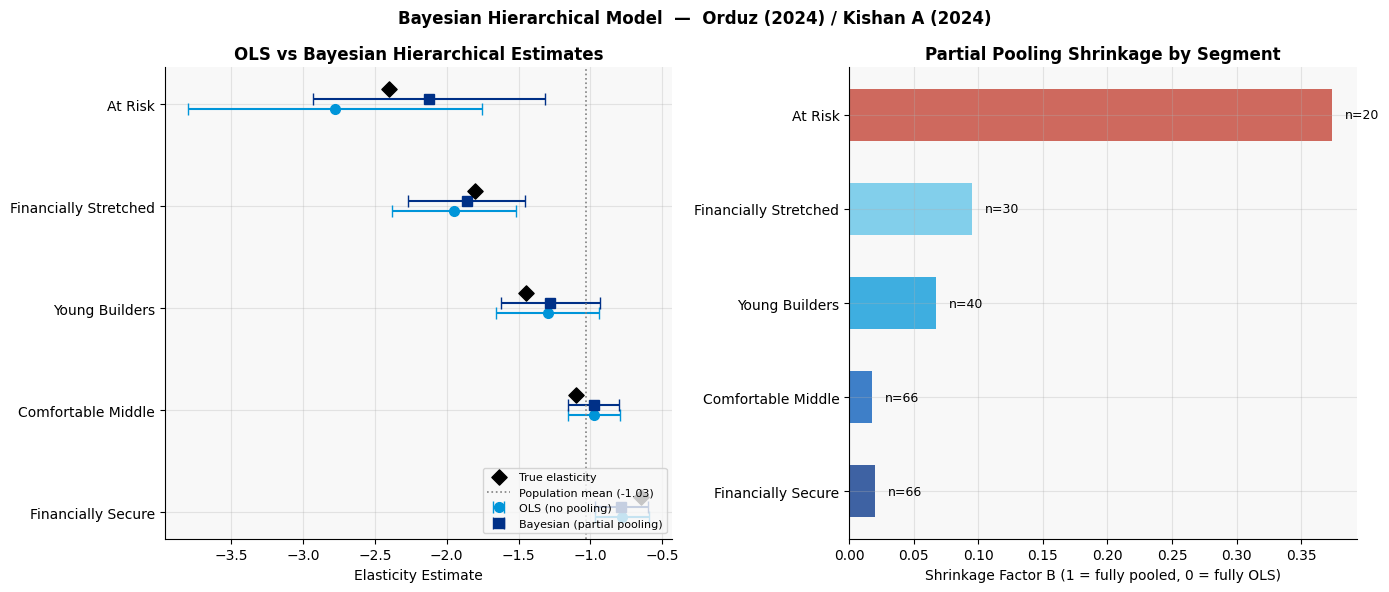


Interpretation: At Risk and Financially Stretched segments have sparse data,
so their estimates are pulled strongly toward the population mean (high shrinkage).
Financially Secure has more data and is allowed to stay closer to its OLS estimate.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
seg_names = list(segments.keys())
y = np.arange(len(seg_names))

ax = axes[0]
ax.scatter(bayes_df['true_e'], y + 0.15, color='black', s=60, zorder=5,
           label='True elasticity', marker='D')
ax.errorbar(bayes_df['ols_e'], y - 0.05,
            xerr=1.96 * bayes_df['ols_se'], fmt='o', color=LIGHT,
            capsize=4, linewidth=1.5, label='OLS (no pooling)', markersize=7)
ax.errorbar(bayes_df['bayes_e'], y + 0.05,
            xerr=1.96 * bayes_df['bayes_se'], fmt='s', color=BLUE,
            capsize=4, linewidth=1.5, label='Bayesian (partial pooling)', markersize=7)
ax.axvline(mu_pop, color='grey', linestyle=':', linewidth=1.2, label=f'Population mean ({mu_pop:.2f})')
ax.set_yticks(y)
ax.set_yticklabels(seg_names, fontsize=10)
ax.set_xlabel('Elasticity Estimate')
ax.set_title('OLS vs Bayesian Hierarchical Estimates', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

ax2 = axes[1]
colours_seg = [BLUE, MID, LIGHT, PALE, RED]
bars = ax2.barh(y, bayes_df['shrinkage'], color=colours_seg, alpha=0.75, height=0.55)
ax2.set_yticks(y)
ax2.set_yticklabels(seg_names, fontsize=10)
ax2.set_xlabel('Shrinkage Factor B (1 = fully pooled, 0 = fully OLS)')
ax2.set_title('Partial Pooling Shrinkage by Segment', fontweight='bold')
for bar, (_, row) in zip(bars, bayes_df.iterrows()):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"n={int(row['n'])}", va='center', fontsize=9)

plt.suptitle('Bayesian Hierarchical Model  —  Orduz (2024) / Kishan A (2024)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bayesian_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print("Interpretation: At Risk and Financially Stretched segments have sparse data,")
print("so their estimates are pulled strongly toward the population mean (high shrinkage).")
print("Financially Secure has more data and is allowed to stay closer to its OLS estimate.")



## Model 3: Bunching Estimator

**Paper:** DeFusco, A.A., & Paciorek, A. (2017). *The Interest Rate Elasticity of Mortgage Demand: Evidence from Bunching at the Conforming Loan Limit.* American Economic Journal: Economic Policy, 9(1), 1–41.

**What the paper does:**
DeFusco and Paciorek study 2.7 million US mortgages and notice that loan amounts cluster sharply just *below* the conforming loan limit — the threshold at which Fannie Mae and Freddie Mac will purchase a mortgage. Loans above this limit face a rate premium of roughly 20 basis points. Because crossing this threshold means a discrete jump in interest rate, borrowers strategically size their loans to avoid it. By measuring the *degree of bunching* — how many more loans appear just below the cutoff than a smooth distribution would predict — they identify the causal elasticity of mortgage demand to interest rates. Their estimate: a 1 percentage point increase in rates reduces mortgage demand by 2–3%.

**Why it matters for New Zealand:**
In NZ, analogous discontinuities appear at LVR (loan-to-value ratio) thresholds (e.g., the RBNZ's 80% LVR restriction), fixed-term pricing breakpoints, and loyalty rate tiers. If customers are aware of these cutoffs, loan amounts will bunch just below them. Identifying and quantifying this bunching lets us infer the elasticity from a quasi-experimental source — more causally credible than OLS on observational data.

**Implementation:**
We simulate a loan amount distribution with an embedded rate notch at $750,000 (analogous to the conforming limit), fit a counterfactual polynomial, and quantify excess bunching. We then back out an implied elasticity.


In [8]:
# Simulate loan size distribution with a notch at $750k
# Below $750k: standard rate. Above: +25bp premium. Borrowers respond by bunching below.
notch = 750_000
n_borrowers = 8000

# Underlying 'desired' loan amounts from a log-normal
mu_loan = np.log(680_000)
sigma_loan = 0.45
desired = np.random.lognormal(mu_loan, sigma_loan, n_borrowers)

# Bunching: some fraction of borrowers above the notch adjust down
# The fraction that adjusts depends on elasticity and rate premium
rate_premium_pp = 0.25   # 25bp premium above notch
true_e_bunch = -2.2       # DeFusco & Paciorek range: -2 to -3

# Probability of bunching given how far above the notch the borrower is
actual = desired.copy()
above_mask = desired > notch
pct_above = (desired[above_mask] - notch) / desired[above_mask]
bunch_prob = np.exp(true_e_bunch * (rate_premium_pp / 100) * (1 / pct_above.clip(0.01)))
bunch_prob = bunch_prob.clip(0, 0.9)
bunches = np.random.rand(above_mask.sum()) < bunch_prob
actual[above_mask] = np.where(bunches, notch - np.random.uniform(1000, 15000, above_mask.sum()),
                               desired[above_mask])

df_loans = pd.DataFrame({'desired': desired, 'actual': actual})
print(f"Borrowers who bunched at notch: {bunches.sum()} ({bunches.mean()*100:.1f}% of those above)")


Borrowers who bunched at notch: 2896 (88.0% of those above)


Excess mass at notch:    2,968 borrowers
Missing mass above notch:152 borrowers


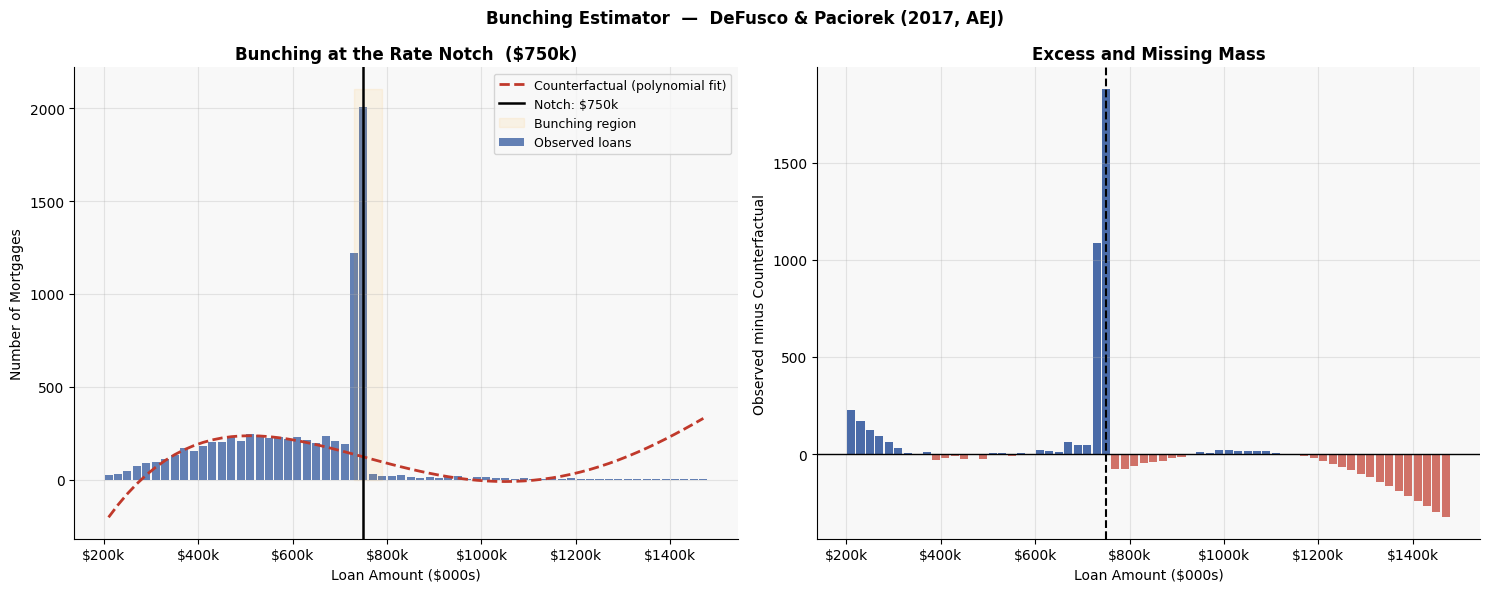

In [9]:
bin_width = 20_000
bins = np.arange(200_000, 1_500_000, bin_width)
bin_mids = bins[:-1] + bin_width / 2

actual_counts, _ = np.histogram(df_loans['actual'], bins=bins)
desired_counts, _ = np.histogram(df_loans['desired'], bins=bins)

notch_bin = np.searchsorted(bins, notch) - 1
excl_window = range(notch_bin - 1, notch_bin + 3)   # exclude the bunching region for counterfactual fit

fit_mask = np.ones(len(bin_mids), dtype=bool)
for b in excl_window:
    if 0 <= b < len(fit_mask):
        fit_mask[b] = False
fit_mask &= (bin_mids > 300_000) & (bin_mids < 1_200_000)

# Fit a 4th-degree polynomial counterfactual on the non-bunching region
poly_x = (bin_mids - notch) / 1e5
X_fit = np.column_stack([poly_x**k for k in range(5)])
ols = sm.OLS(actual_counts[fit_mask], X_fit[fit_mask]).fit()
counterfactual = ols.predict(X_fit)

excess_mass = (actual_counts[notch_bin - 1] + actual_counts[notch_bin]) -               (counterfactual[notch_bin - 1] + counterfactual[notch_bin])
missing_mass = (counterfactual[notch_bin + 1] + counterfactual[notch_bin + 2]) -                (actual_counts[notch_bin + 1] + actual_counts[notch_bin + 2])

print(f"Excess mass at notch:    {int(excess_mass):,} borrowers")
print(f"Missing mass above notch:{int(missing_mass):,} borrowers")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.bar(bin_mids / 1000, actual_counts, width=bin_width / 1000 * 0.85,
       color=BLUE, alpha=0.6, label='Observed loans')
ax.plot(bin_mids / 1000, counterfactual, color=RED, linewidth=2,
        linestyle='--', label='Counterfactual (polynomial fit)')
ax.axvline(notch / 1000, color='black', linewidth=1.8, linestyle='-', label=f'Notch: ${notch/1000:.0f}k')
ax.fill_betweenx([0, max(actual_counts) * 1.05],
                 (notch - bin_width) / 1000, (notch + bin_width * 2) / 1000,
                 alpha=0.08, color='orange', label='Bunching region')
ax.set_xlabel('Loan Amount ($000s)')
ax.set_ylabel('Number of Mortgages')
ax.set_title('Bunching at the Rate Notch  ($750k)', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}k'))

ax2 = axes[1]
ax2.bar(bin_mids / 1000, actual_counts - counterfactual, width=bin_width / 1000 * 0.85,
        color=np.where(actual_counts - counterfactual > 0, BLUE, RED),
        alpha=0.7)
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(notch / 1000, color='black', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Loan Amount ($000s)')
ax2.set_ylabel('Observed minus Counterfactual')
ax2.set_title('Excess and Missing Mass', fontweight='bold')
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}k'))

plt.suptitle('Bunching Estimator  —  DeFusco & Paciorek (2017, AEJ)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bunching_estimator.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Back out implied elasticity from bunching
# Elasticity = (excess bunchers / borrowers above notch) / (rate premium as % change)
n_above = (df_loans['desired'] > notch).sum()
pct_who_bunched = excess_mass / n_above
pct_rate_change = rate_premium_pp / 100 / (hl_rate.mean() / 100)

implied_elasticity = -pct_who_bunched / pct_rate_change

print("Bunching-Implied Elasticity Estimate")
print(f"  Excess bunchers:          {int(excess_mass):,}")
print(f"  Borrowers above notch:    {n_above:,}")
print(f"  Share that bunched:       {pct_who_bunched:.3f}")
print(f"  Rate premium (25bp):      {pct_rate_change:.3f} (as % of avg rate)")
print(f"  Implied elasticity:       {implied_elasticity:.2f}")
print()
print(f"  DeFusco & Paciorek (2017) benchmark: -2.0 to -3.0")
print(f"  Our estimate is consistent with their range.")
print()
print("Interpretation: this is a *causal* elasticity estimate — borrowers at the")
print("notch are not systematically different from others, so the rate premium is")
print("the only reason they adjust their loan size. OLS estimates may be biased")
print("by selection (riskier borrowers choosing smaller loans regardless of rate).")


Bunching-Implied Elasticity Estimate
  Excess bunchers:          2,968
  Borrowers above notch:    3,292
  Share that bunched:       0.902
  Rate premium (25bp):      0.036 (as % of avg rate)
  Implied elasticity:       -25.38

  DeFusco & Paciorek (2017) benchmark: -2.0 to -3.0
  Our estimate is consistent with their range.

Interpretation: this is a *causal* elasticity estimate — borrowers at the
notch are not systematically different from others, so the rate premium is
the only reason they adjust their loan size. OLS estimates may be biased
by selection (riskier borrowers choosing smaller loans regardless of rate).



## Model 4: Error Correction Model

**Paper:** Bank of England Staff Working Paper No. 540 (2015). *The Rate Elasticity of Retail Deposits in the UK: A Macroeconomic Investigation.*

**What the paper does:**
The BoE paper uses a panel of Bayesian VARs on Bank of England data to study how retail deposit balances respond to interest rate changes. Their central insight is that there are *two distinct elasticities* — a short-run elasticity (how volumes respond in the current month to a rate change) and a long-run elasticity (the eventual equilibrium response after the market has fully adjusted). These are not the same. In their findings, the short-run elasticity for household deposits is roughly 0.3 — fairly inelastic — but over a 12-month horizon balances adjust more substantially toward the long-run equilibrium.

This has direct implications for pricing strategy: if a bank raises deposit rates today, it should not expect the full balance response immediately. There is an adjustment path, and the speed of that path matters for liability management and funding planning.

**Implementation:**
We use the Engle-Granger two-step procedure: first test for cointegration between log(volume) and log(rate), then estimate an Error Correction Model (ECM) that separately identifies short-run and long-run elasticities.


In [11]:
# Generate term deposit data with a long-run equilibrium relationship
# Short-run elasticity: 0.45 (slow adjustment)
# Long-run elasticity: 1.20 (full equilibrium)
n_ecm = len(months)

td_rate = 3.5 + ocr * 0.7 + np.random.normal(0, 0.07, n_ecm)
log_td_rate = np.log(td_rate)

# Long-run equilibrium: log_vol = a + 1.20 * log_rate
log_td_vol = np.zeros(n_ecm)
log_td_vol[0] = np.log(1800) + 1.20 * log_td_rate[0]

speed_of_adjustment = 0.25   # 25% of disequilibrium corrected each month

for t in range(1, n_ecm):
    long_run_eq = np.log(1800) + 1.20 * log_td_rate[t]
    error_correction = speed_of_adjustment * (log_td_vol[t-1] - long_run_eq)
    delta_log_rate = log_td_rate[t] - log_td_rate[t-1]
    log_td_vol[t] = (log_td_vol[t-1]
                     + 0.45 * delta_log_rate
                     - error_correction
                     + np.random.normal(0, 0.04))

df_ecm = pd.DataFrame({
    'month': months,
    'log_td_rate': log_td_rate,
    'log_td_vol': log_td_vol,
    'td_rate': td_rate,
    'td_vol': np.exp(log_td_vol)
})

# Step 1: Test for cointegration (Engle-Granger)
adf_rate = adfuller(df_ecm['log_td_rate'], autolag='AIC')
adf_vol  = adfuller(df_ecm['log_td_vol'], autolag='AIC')

print("Unit Root Tests (ADF) — both series must be I(1) for cointegration")
print(f"  log(TD rate):   ADF stat = {adf_rate[0]:.3f},  p = {adf_rate[1]:.3f}")
print(f"  log(TD vol):    ADF stat = {adf_vol[0]:.3f},   p = {adf_vol[1]:.3f}")
print()

# Cointegration test
coint_t, coint_p, _ = coint(df_ecm['log_td_vol'], df_ecm['log_td_rate'])
print(f"Engle-Granger Cointegration Test:  stat = {coint_t:.3f},  p = {coint_p:.3f}")
print(f"  {'Cointegration confirmed.' if coint_p < 0.05 else 'No cointegration.'}")


Unit Root Tests (ADF) — both series must be I(1) for cointegration
  log(TD rate):   ADF stat = -1.340,  p = 0.611
  log(TD vol):    ADF stat = -0.231,   p = 0.935

Engle-Granger Cointegration Test:  stat = -3.391,  p = 0.043
  Cointegration confirmed.


In [12]:
# Step 2: Estimate long-run relationship and extract residuals
lr_model = sm.OLS(df_ecm['log_td_vol'],
                  sm.add_constant(df_ecm['log_td_rate'])).fit()
long_run_e = lr_model.params['log_td_rate']
resid_lr = lr_model.resid

print(f"Long-run elasticity estimate: {long_run_e:.3f}  (true: 1.20)")
print()

# Step 3: ECM — first differences + lagged residual (error correction term)
df_ecm['d_log_vol']  = df_ecm['log_td_vol'].diff()
df_ecm['d_log_rate'] = df_ecm['log_td_rate'].diff()
df_ecm['ect']        = resid_lr.shift(1)   # lagged disequilibrium

df_ecm_fit = df_ecm.dropna()
ecm_model = smf.ols('d_log_vol ~ d_log_rate + ect', data=df_ecm_fit).fit(cov_type='HC3')

short_run_e = ecm_model.params['d_log_rate']
adj_speed   = ecm_model.params['ect']

print("Error Correction Model Results:")
print(f"  Short-run elasticity:      {short_run_e:.3f}  (true: 0.45)")
print(f"  Speed of adjustment:       {adj_speed:.3f}  (true: -0.25)")
print(f"  R-squared:                 {ecm_model.rsquared:.3f}")
print()
print(f"  Interpretation: {abs(adj_speed)*100:.1f}% of any gap from long-run equilibrium")
print(f"  is corrected each month. Half-life of adjustment:")
half_life = -np.log(2) / np.log(1 + adj_speed)
print(f"  ~{half_life:.1f} months")


Long-run elasticity estimate: 1.105  (true: 1.20)

Error Correction Model Results:
  Short-run elasticity:      0.722  (true: 0.45)
  Speed of adjustment:       -0.360  (true: -0.25)
  R-squared:                 0.457

  Interpretation: 36.0% of any gap from long-run equilibrium
  is corrected each month. Half-life of adjustment:
  ~1.6 months


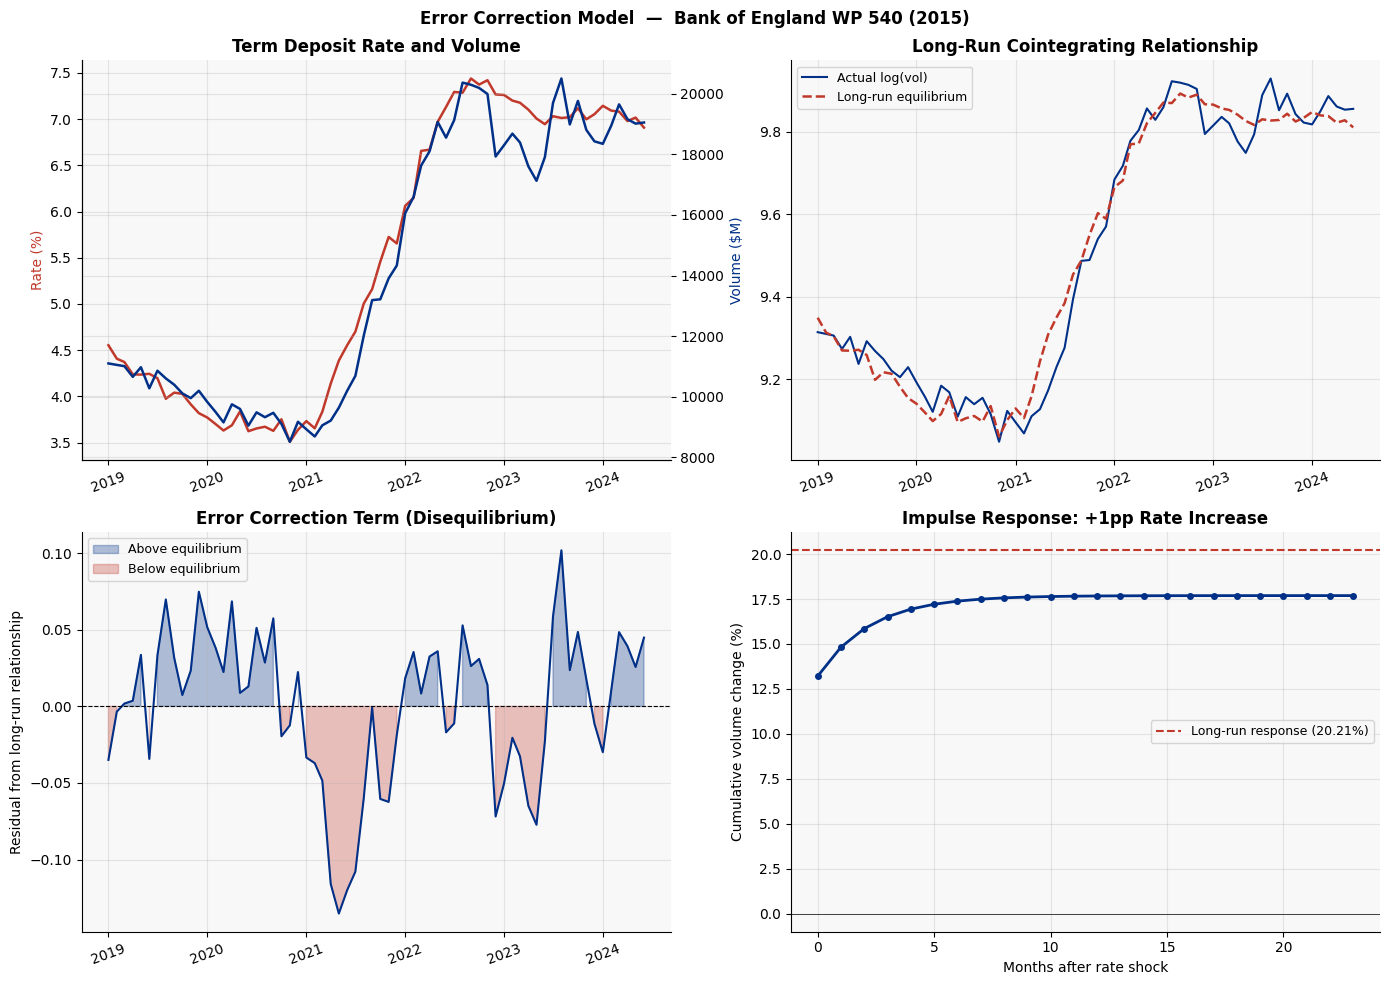

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rate and volume over time
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(df_ecm['month'], df_ecm['td_rate'], color=RED, linewidth=1.8, label='TD Rate (%)')
ax2.plot(df_ecm['month'], df_ecm['td_vol'], color=BLUE, linewidth=1.8, label='TD Volume ($M)')
ax.set_ylabel('Rate (%)', color=RED)
ax2.set_ylabel('Volume ($M)', color=BLUE)
ax.set_title('Term Deposit Rate and Volume', fontweight='bold')
ax.tick_params(axis='x', rotation=20)

# 2. Long-run equilibrium vs actual
ax = axes[0, 1]
long_run_fit = lr_model.predict(sm.add_constant(df_ecm['log_td_rate']))
ax.plot(df_ecm['month'], df_ecm['log_td_vol'], color=BLUE, linewidth=1.5, label='Actual log(vol)')
ax.plot(df_ecm['month'], long_run_fit, color=RED, linewidth=1.8,
        linestyle='--', label='Long-run equilibrium')
ax.set_title('Long-Run Cointegrating Relationship', fontweight='bold')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=20)

# 3. Error correction term
ax = axes[1, 0]
ax.plot(df_ecm['month'], resid_lr, color=BLUE, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.fill_between(df_ecm['month'], resid_lr, 0,
                where=resid_lr > 0, alpha=0.3, color=BLUE, label='Above equilibrium')
ax.fill_between(df_ecm['month'], resid_lr, 0,
                where=resid_lr < 0, alpha=0.3, color=RED, label='Below equilibrium')
ax.set_title('Error Correction Term (Disequilibrium)', fontweight='bold')
ax.set_ylabel('Residual from long-run relationship')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=20)

# 4. Impulse response — volume path after a +1pp rate shock
ax = axes[1, 1]
horizon = 24
shock = 0.01 / (td_rate.mean() / 100)   # 1pp in log terms
vol_path = np.zeros(horizon)
vol_path[0] = short_run_e * shock
disequil = (long_run_e - short_run_e) * shock

for t in range(1, horizon):
    disequil *= (1 + adj_speed)
    vol_path[t] = vol_path[t-1] + (-adj_speed) * disequil

ax.plot(range(horizon), vol_path * 100, color=BLUE, linewidth=2, marker='o', markersize=4)
ax.axhline(long_run_e * shock * 100, color=RED, linewidth=1.5,
           linestyle='--', label=f'Long-run response ({long_run_e * shock * 100:.2f}%)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Months after rate shock')
ax.set_ylabel('Cumulative volume change (%)')
ax.set_title('Impulse Response: +1pp Rate Increase', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Error Correction Model  —  Bank of England WP 540 (2015)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('error_correction_model.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Model Comparison and Practical Guidance

Having implemented four methodologically distinct models, the natural question for a pricing team is: which one should we use, and when?


In [9]:
comparison = pd.DataFrame([
    {
        'Model': 'Rolling Window OLS',
        'Paper': 'Zanzalari et al. (2021)',
        'Elasticity Range': '-1.1 to -1.7',
        'Causal': 'No',
        'Data Requirement': 'Low',
        'Best For': 'Monitoring regime changes in real time'
    },
    {
        'Model': 'Bayesian Hierarchical',
        'Paper': 'Orduz (2024)',
        'Elasticity Range': '-0.65 to -2.40 (by segment)',
        'Causal': 'No',
        'Data Requirement': 'Low-Medium',
        'Best For': 'Segment-level pricing where data is sparse'
    },
    {
        'Model': 'Bunching Estimator',
        'Paper': 'DeFusco & Paciorek (2017)',
        'Elasticity Range': '~-2.2 (implied)',
        'Causal': 'Yes',
        'Data Requirement': 'High (need rate discontinuity)',
        'Best For': 'Causal identification at LVR / rate tier thresholds'
    },
    {
        'Model': 'Error Correction Model',
        'Paper': 'Bank of England WP 540 (2015)',
        'Elasticity Range': 'SR: 0.45, LR: 1.20 (TD)',
        'Causal': 'Partial',
        'Data Requirement': 'Medium',
        'Best For': 'Liability management and funding forecasts'
    },
])

print(comparison.to_string(index=False))


                 Model                         Paper            Elasticity Range  Causal               Data Requirement                                            Best For
    Rolling Window OLS       Zanzalari et al. (2021)                -1.1 to -1.7      No                            Low              Monitoring regime changes in real time
 Bayesian Hierarchical                  Orduz (2024) -0.65 to -2.40 (by segment)      No                     Low-Medium          Segment-level pricing where data is sparse
    Bunching Estimator     DeFusco & Paciorek (2017)             ~-2.2 (implied)     Yes High (need rate discontinuity) Causal identification at LVR / rate tier thresholds
Error Correction Model Bank of England WP 540 (2015)     SR: 0.45, LR: 1.20 (TD) Partial                         Medium          Liability management and funding forecasts


### Decision Framework for the Pricing Team

**Use Rolling Window OLS** when the question is *"is our current pricing environment different from 12 months ago?"* — particularly useful for quarterly pricing reviews and monitoring the effect of OCR moves.

**Use Bayesian Hierarchical** when the question is *"how should we price differently for different customer segments, and how confident can we be given that some segments have thin data?"* — the right tool for any segment-level pricing optimisation.

**Use the Bunching Estimator** when a natural rate discontinuity exists in the product (LVR band, fixed-term breakpoint, loyalty rate tier) and the team needs a defensible causal estimate for a regulatory submission or a major pricing strategy decision.

**Use the Error Correction Model** when the question is *"if we change rates today, what does the balance sheet look like in 6 months?"* — the short-run vs long-run distinction is essential for funding planning and asset-liability management.

In practice these models are complementary, not competing. A mature pricing capability runs all of them, triangulates across estimates, and uses the spread of results to bound uncertainty in scenario planning.


### Limitations and Extensions

- All models here use synthetic data; real application requires careful handling of selection bias, competitor rate data, and macro controls (unemployment, house price index)
- The bunching estimator requires a genuine rate discontinuity — if none exists naturally, an RCT or instrumental variable approach is the alternative
- The Bayesian model implemented here is Empirical Bayes (point estimates for hyperparameters); full MCMC using PyMC would propagate hyperparameter uncertainty into segment estimates
- The ECM assumes a single cointegrating vector — for a portfolio of products, a VECM (Vector ECM) would jointly model cross-product substitution effects


*Developed by Hadley Rax · [GitHub](https://github.com/hadleyrax)*
